In [20]:
import pandas as pd

In [21]:
df = pd.read_csv('GooglePlayStore_wild.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  object 
 2   Category        10840 non-null  object 
 3   Rating          9366 non-null   float64
 4   Reviews         10840 non-null  int64  
 5   Size            10840 non-null  object 
 6   Installs        10840 non-null  object 
 7   Type            10839 non-null  object 
 8   Price           10840 non-null  object 
 9   Content Rating  10840 non-null  object 
 10  Genres          10840 non-null  object 
 11  Last Updated    10840 non-null  object 
 12  Current Ver     10832 non-null  object 
 13  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 1.2+ MB
None


In [22]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
print(df['Rating'].mean())
df['Rating'].fillna(df['Rating'].mean(), inplace = True)

4.191757420456972


C:\Users\ASUS\AppData\Local\Temp\ipykernel_260\38389052.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace = True)


In [23]:
df['Type'].fillna('Varies with device', inplace = True)
df['Current Ver'].fillna('Varies with device', inplace = True)
df['Android Ver'].fillna('Varies with device', inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_260\1868876005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type'].fillna('Varies with device', inplace = True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_260\1868876005.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [24]:
print(df['Android Ver'].sample(10))

8058            4.1 and up
4605    Varies with device
2373            4.1 and up
6167            2.3 and up
3307    Varies with device
1428            4.1 and up
2653            4.4 and up
4920            4.2 and up
7407            2.3 and up
9745    Varies with device
Name: Android Ver, dtype: object


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  object 
 2   Category        10840 non-null  object 
 3   Rating          10840 non-null  float64
 4   Reviews         10840 non-null  int64  
 5   Size            10840 non-null  object 
 6   Installs        10840 non-null  object 
 7   Type            10840 non-null  object 
 8   Price           10840 non-null  object 
 9   Content Rating  10840 non-null  object 
 10  Genres          10840 non-null  object 
 11  Last Updated    10840 non-null  object 
 12  Current Ver     10840 non-null  object 
 13  Android Ver     10840 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 1.2+ MB
None


In [26]:
print(df.drop_duplicates(inplace=True))

None


In [27]:
df['Price'] = df['Price'].str.replace('$','').astype(float)

In [28]:
print(df['Price'].sample(10))

7590    0.00
4377    0.00
146     0.00
4992    0.00
4012    0.00
2899    0.00
1807    0.00
7154    0.00
9480    1.99
508     0.00
Name: Price, dtype: float64


In [29]:
df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '').astype(int)

In [30]:
print(df['Installs'].sample(10))

2564       5000000
6884         10000
3117    1000000000
8242             1
1122       1000000
8546          5000
2242       1000000
1166         10000
8267          1000
8098         50000
Name: Installs, dtype: int64


In [31]:
print(df['Size'].sample(10))

958      Varies with device
1097     Varies with device
1905                    97M
693                     19M
5192                    13M
6573                    49M
5839                    13M
10279                   40M
550                     23M
10238                  4.5M
Name: Size, dtype: object


In [32]:
print(df['Size'].value_counts())

def set_size(size):
    if size[-1] == 'M':
        return float(size[:-1])
    elif size[-1] == 'k':
        return float(size[:-1]) / 1024
    return -1
df['Size'] = df['Size'].apply(set_size)
df['Size'] = df['Size'].replace('Varies with device', '-1')

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
430k                     1
429k                     1
200k                     1
460k                     1
619k                     1
Name: count, Length: 461, dtype: int64


In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  object 
 2   Category        10840 non-null  object 
 3   Rating          10840 non-null  float64
 4   Reviews         10840 non-null  int64  
 5   Size            10840 non-null  float64
 6   Installs        10840 non-null  int64  
 7   Type            10840 non-null  object 
 8   Price           10840 non-null  float64
 9   Content Rating  10840 non-null  object 
 10  Genres          10840 non-null  object 
 11  Last Updated    10840 non-null  object 
 12  Current Ver     10840 non-null  object 
 13  Android Ver     10840 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 1.2+ MB
None


In [34]:
import pandas as pd
import matplotlib.pyplot as plt


<Axes: ylabel='Frequency'>

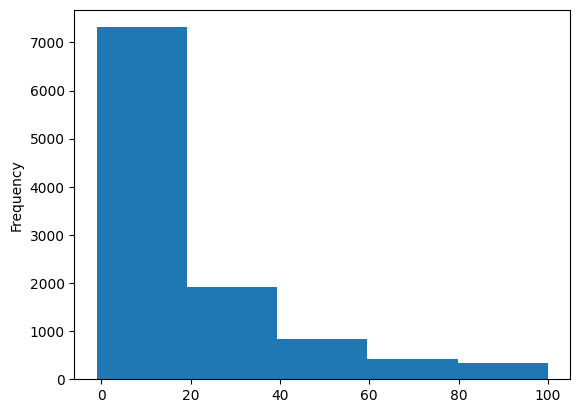

In [35]:
df['Size'].plot(kind= 'hist', bins=5)

<Axes: >

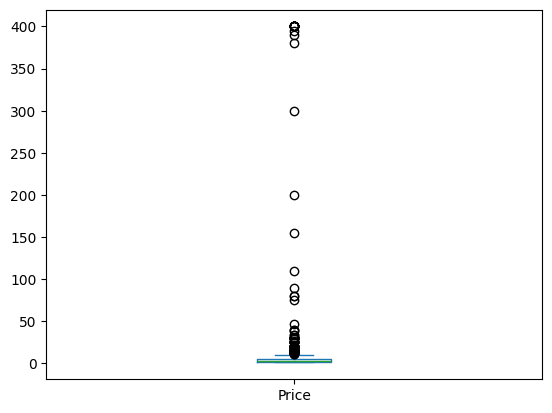

In [37]:
df[df['Type'] == 'Paid']['Price'].plot(kind = 'box')

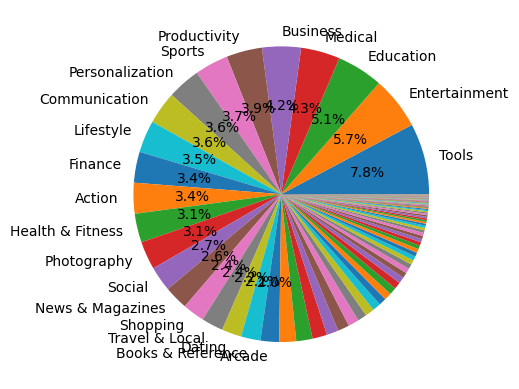

In [45]:
counts = df['Genres'].value_counts()
total = counts.sum()
labels = [label if (count / total) * 100 >= 2 else '' for label, count in counts.items()]

def autopct_if_large(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

counts.plot(kind='pie', labels=labels, autopct=autopct_if_large)
plt.ylabel('')  # remove default y-label
plt.show()

<Axes: xlabel='Rating'>

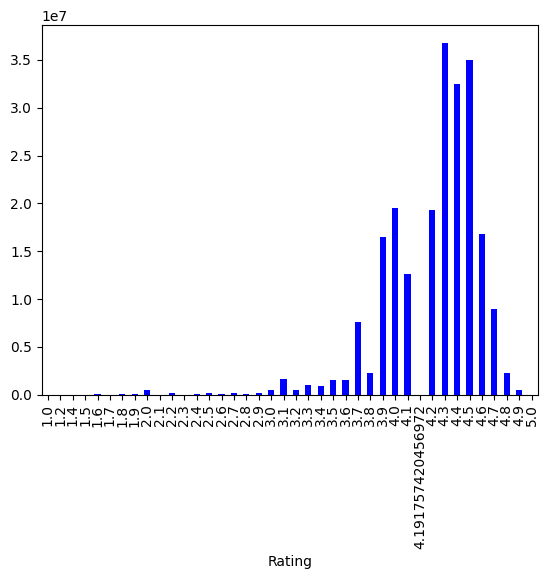

In [49]:
d1 = df[df['Type'] == 'Free'].groupby('Rating')['Installs'].mean()
d1.plot(kind='bar', color='blue')

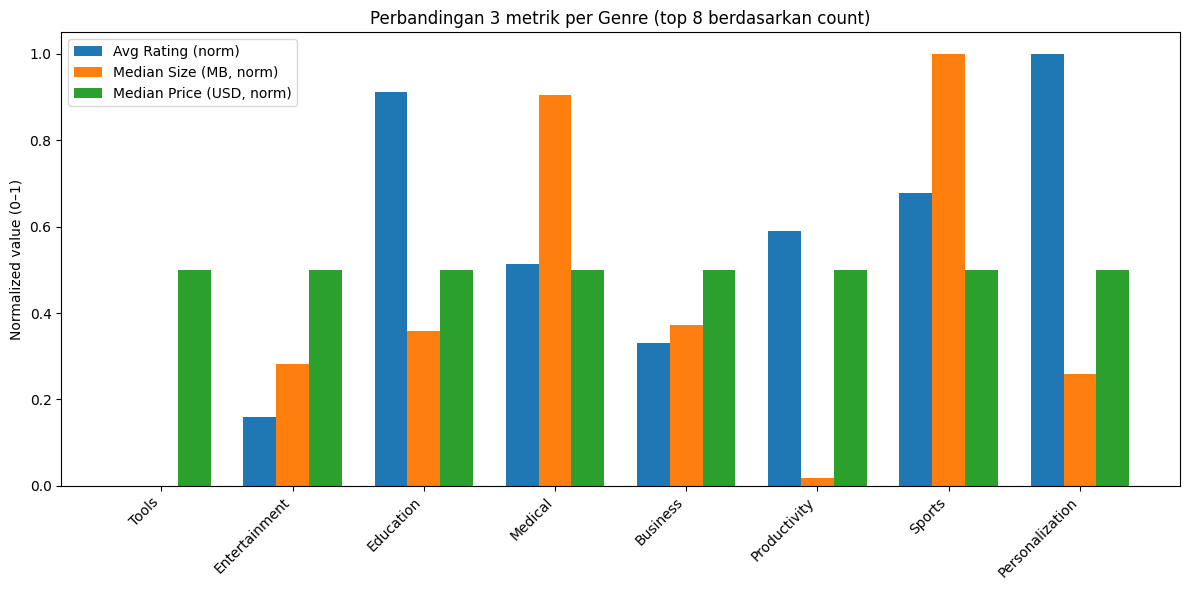

In [50]:
# grouped comparison chart: avg_rating, median_size, median_price (normalized) for top genres
top = agg.sort_values('count', ascending=False).head(8).copy()

# normalize columns to 0-1 so they are comparable on one chart
cols = ['avg_rating', 'median_size', 'median_price']
for c in cols:
    mn, mx = top[c].min(), top[c].max()
    top[c + '_norm'] = 0.5 if mx == mn else (top[c] - mn) / (mx - mn)

n = len(top)
ind = list(range(n))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar([i - width for i in ind], top['avg_rating_norm'], width=width, label='Avg Rating (norm)')
plt.bar(ind, top['median_size_norm'], width=width, label='Median Size (MB, norm)')
plt.bar([i + width for i in ind], top['median_price_norm'], width=width, label='Median Price (USD, norm)')

plt.xticks(ind, top.index, rotation=45, ha='right')
plt.ylabel('Normalized value (0–1)')
plt.title('Perbandingan 3 metrik per Genre (top 8 berdasarkan count)')
plt.legend()
plt.tight_layout()
plt.show()